In [1]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from scipy.ndimage import gaussian_filter

- images/p5/background-plate.jpg
-- source: Image by steve from pixabay
- code/assets/greenscreenvideo.mp4
-- source: free stock video from Mixkit

Used the code/asset/ingest_greenscreen.py to feed it the greenscreenvideo and generate the frames stored in images/p5/frames
```
◄ 0s ◎ python code/assets/ingest_greenscreen.py code/assets/greenscreenvideo.mp4 --frames 48 --report
decoded 295 frames at 1280x720
(no reference keyer available -- taking the middle window and skipping 
the scoring pass; judge the footage by eye against the checklist in the handout)
best window: frames 123..170 
fractional alpha: not measured 
wrote 48 frames -> /home/bsal/Documents/IIIT/Monsoon2026/DIP/DIP_Assignment_1/images/p5/frames
wrote subject_1080p.png and subject_480p.png from the middle frame

NOTE: _solution_alpha.png is left alone -- it is the synthetic ground truth
instructor/verify.py measures against, and real footage has none. 
--report needs the reference keyer; skipped 

Next: 
python assets/check_asset.py --role greenscreen ../images/p5/frames/f000.png 
python instructor/verify.py
```

The chosen resources met the requirement stated in the problem
- the video is not AI generated, has a greenscreen, has hair, has motion blur and doesnot contain any watermark
- the background plate is larger than 2.5x the video, not AI generated and has no watermark.

48 frames of size (720, 1280)
background plate: (3264, 4928, 3)


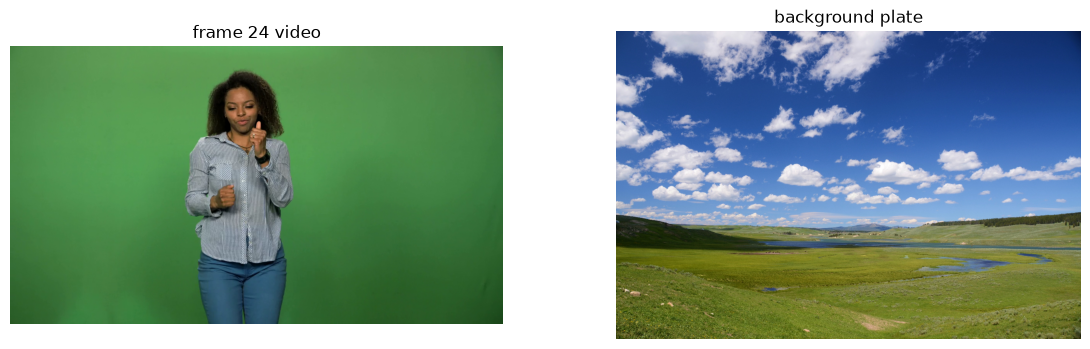

In [2]:
frames = []
for i in range(48):
      frames.append(np.asarray(Image.open(f"../../images/p5/frames/f{i:03d}.png").convert("RGB")))

background = np.asarray(Image.open("../../images/p5/background-plate.jpg").convert("RGB"))
frame = frames[24]
h, w = frame.shape[:2]

out = Path("q5_outputs") 
out.mkdir(exist_ok=True)

print(len(frames), "frames of size", (h, w))
print("background plate:", background.shape)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(frame); ax[0].set_title("frame 24 video"); ax[0].axis("off")
ax[1].imshow(background[::4, ::4]); ax[1].set_title("background plate"); ax[1].axis("off")
plt.show()

In [3]:
def to_ycbcr(rgb):
    """BT.601 full-range YCbCr. Y is brightness, Cb/Cr are the colour part."""
    r = rgb[..., 0].astype(np.float32)
    g = rgb[..., 1].astype(np.float32)
    b = rgb[..., 2].astype(np.float32)
    y  = 0.299 * r + 0.587 * g + 0.114 * b
    cb = -0.168736 * r - 0.331264 * g + 0.5 * b + 128
    cr = 0.5 * r - 0.418688 * g - 0.081312 * b + 128
    return np.stack([y, cb, cr], axis=-1)

def key_naive_rgb(rgb, thresh):
    r = rgb[..., 0].astype(np.float32)
    g = rgb[..., 1].astype(np.float32)
    b = rgb[..., 2].astype(np.float32)
    dominance = g - np.maximum(r, b)
    return (dominance <= thresh).astype(np.float32)

def estimate_key_colour(rgb, border=24):
    ycc = to_ycbcr(rgb)
    ring = np.concatenate([
        ycc[:border,  :, 1:3].reshape(-1, 2),
        ycc[-border:, :, 1:3].reshape(-1, 2),
        ycc[:, :border,  1:3].reshape(-1, 2),
        ycc[:, -border:, 1:3].reshape(-1, 2),
    ])
    return np.median(ring, axis=0)

def chroma_distance(rgb, key_cbcr):
    ycc = to_ycbcr(rgb)
    return np.hypot(ycc[..., 1] - key_cbcr[0], ycc[..., 2] - key_cbcr[1])

estimated backing colour (Cb, Cr): [108.6 104.1]


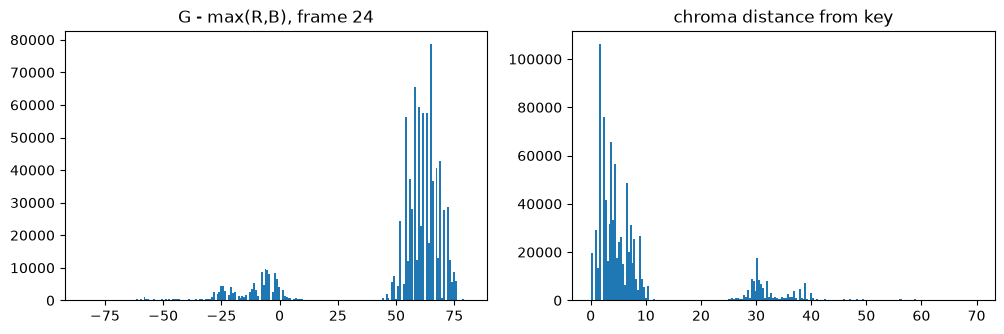

dominance between 5 and 40 : 0.007
distance between 12 and 20 : 0.0029


In [4]:
dominance = frame[..., 1].astype(float) - np.maximum(frame[..., 0], frame[..., 2]).astype(float)
key = estimate_key_colour(frame)
dist = chroma_distance(frame, key)
print("estimated backing colour (Cb, Cr):", key.round(1))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].hist(dominance.ravel(), bins=200); ax[0].set_title("G - max(R,B), frame 24")
ax[1].hist(dist.ravel(), bins=200);      ax[1].set_title("chroma distance from key")
plt.show()

print("dominance between 5 and 40 :", round(float(((dominance > 5) & (dominance < 40)).mean()), 4))
print("distance between 12 and 20 :", round(float(((dist > 12) & (dist < 20)).mean()), 4))

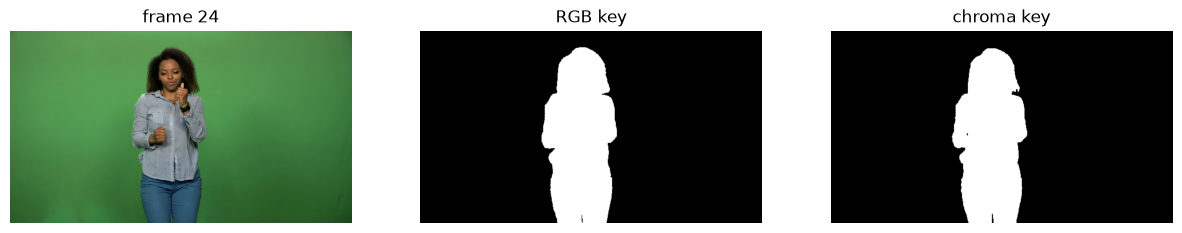

In [5]:
alpha_rgb = key_naive_rgb(frame, 40)
alpha_chroma = (dist > 20).astype(np.float32)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(frame);                     ax[0].set_title("frame 24")
ax[1].imshow(alpha_rgb, cmap="gray");    ax[1].set_title(f"RGB key")
ax[2].imshow(alpha_chroma, cmap="gray"); ax[2].set_title(f"chroma key")
for a in ax: a.axis("off")
plt.savefig(out / "5_1_keys.png", dpi=120, bbox_inches="tight")
plt.show()

In [6]:
sure_backing = dist < 20 / 2
rgb_wrong = (alpha_rgb == 1) & sure_backing
print("pixels the RGB key gets wrong:", int(rgb_wrong.sum()),f"({100 * rgb_wrong.mean():.3f}% of the frame)")

pixels the RGB key gets wrong: 460 (0.050% of the frame)


Identified RGB Failure Pixel at (x=594, y=62):
  RGB: (84, 121, 72) -> G - max(R, B) = 37
  YCbCr: Y=104.4, Cb=109.7, Cr=113.5
  Chroma Distance from key: 9.43


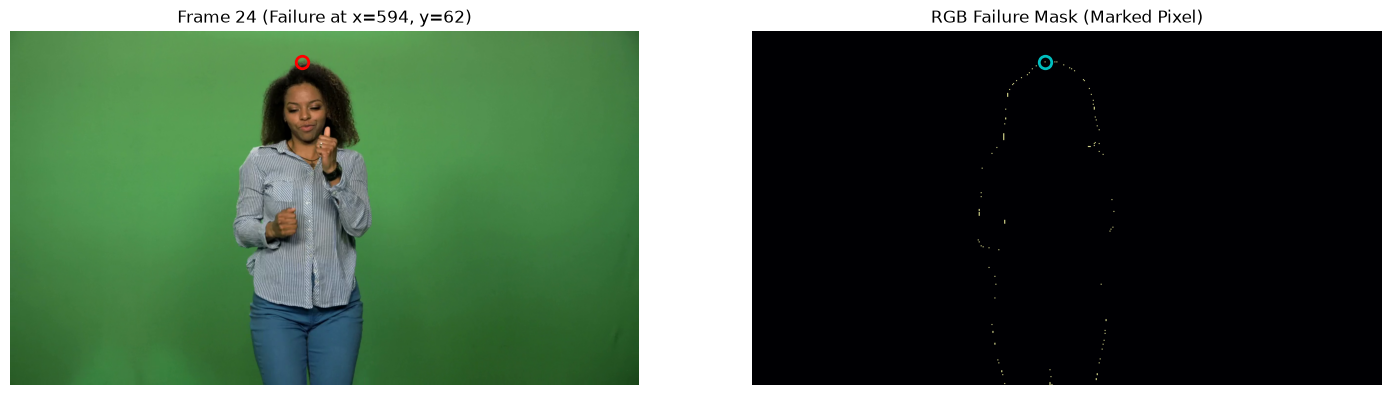

In [7]:
fail_y, fail_x = np.where(rgb_wrong)
py, px = int(fail_y[0]), int(fail_x[0])

# Pixel color values
r_val, g_val, b_val = frame[py, px]
ycc_val = to_ycbcr(frame[py:py+1, px:px+1])[0, 0]
excess_val = int(g_val) - max(int(r_val), int(b_val))
c_dist_val = float(dist[py, px])

print(f"Identified RGB Failure Pixel at (x={px}, y={py}):")
print(f"  RGB: ({r_val}, {g_val}, {b_val}) -> G - max(R, B) = {excess_val}")
print(f"  YCbCr: Y={ycc_val[0]:.1f}, Cb={ycc_val[1]:.1f}, Cr={ycc_val[2]:.1f}")
print(f"  Chroma Distance from key: {c_dist_val:.2f}")


fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].imshow(frame)
ax[0].plot(px, py, 'ro', markersize=9, fillstyle='none', markeredgewidth=2)
ax[0].set_title(f"Frame 24 (Failure at x={px}, y={py})")

ax[1].imshow(rgb_wrong, cmap="inferno")
ax[1].plot(px, py, 'co', markersize=9, fillstyle='none', markeredgewidth=2)
ax[1].set_title("RGB Failure Mask (Marked Pixel)")

for a in ax:
    a.axis("off")
plt.tight_layout()
plt.savefig(out / "5_1_rgb_failure_pixel.png", dpi=120, bbox_inches="tight")
plt.show()

Our backing is evenly lit and hence the failure is mild (less than 0.1 percent). 

The error pixel shown has a very small difference from the chosen threshold and if we chose threshold to be 37 we get 0 pixel error thats because the background is well lit and the error are minor things caused due to the choice of the threshold. 

The main issue of using a RGB based method is hence not reflected in our footage sample, We construct a case where the RGB rule fails with variable lighting effects.

backing colour: [ 60. 122.  64.]
dominance at bright  : 58.0
dominance at the dark: 17.4
chroma distance from dark to bright: 0.2 11.5
RGB key removal percentage: 43.1
chroma key removal percentage: 100.0


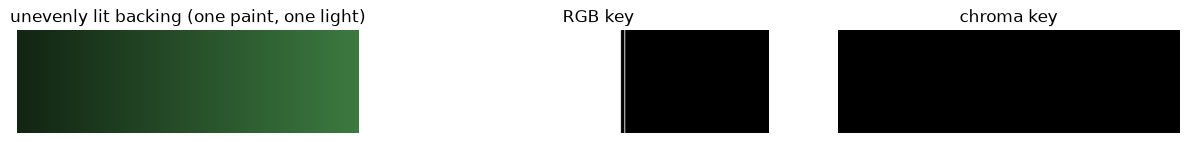

In [8]:
ring_rgb = np.concatenate([frame[:24].reshape(-1, 3), frame[-24:].reshape(-1, 3),
                           frame[:, :24].reshape(-1, 3), frame[:, -24:].reshape(-1, 3)])
paint = np.median(ring_rgb, axis=0)
print("backing colour:", paint)

light = 0.3 + 0.7 * np.linspace(0, 1, 800)
panel = (np.tile(light, (240, 1))[..., None] * paint).astype(np.uint8)


key_panel = estimate_key_colour(panel)
d_panel = chroma_distance(panel, key_panel)
alpha_rgb_panel = key_naive_rgb(panel, 40)
alpha_chroma_panel = (d_panel > 20).astype(np.float32)

full = float(paint[1] - max(paint[0], paint[2]))
print("dominance at bright  :", round(full, 1))
print("dominance at the dark:", round(0.3 * full, 1))
print("chroma distance from dark to bright:", round(float(d_panel.min()), 1),round(float(d_panel.max()), 1))
print("RGB key removal percentage:", round(100 * (1 - float(alpha_rgb_panel.mean())), 1))
print("chroma key removal percentage:", round(100 * (1 - float(alpha_chroma_panel.mean())), 1))

fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].imshow(panel); ax[0].set_title("unevenly lit backing (one paint, one light)")
ax[1].imshow(alpha_rgb_panel, cmap="gray"); ax[1].set_title("RGB key")
ax[2].imshow(alpha_chroma_panel, cmap="gray"); ax[2].set_title("chroma key")
for a in ax: a.axis("off")
plt.savefig(out / "5_1_constructed.png", dpi=120, bbox_inches="tight")
plt.show()

In this constructed testcase we create the backing consisting of uneven lighting. In such a case we notice that the RGB key removes only 67.8% removal whereas a chroma key removes 100% removal.

The reason an RGB key fails in this case is because the RGB channel represents both the brightness and color. Because of this the G - max(R,B) value scales with the total brightness. So there are places where the lighting is not consistent which is missed by the pure rgb method.

As the chosen stock footage is well lit there was no major error in the rgb method. 

Proving with a counter example:
(8,50,15) is a dark (shadow) green region whereas (30,180,40) is a well lit green region the dominance (green - max(red, blue)) = 35 for dark and 140 for well lit. Even though both places show a strong green tint one of them lie above the threshold and one of them lies below leading the shadow/dark floating in the composite. 

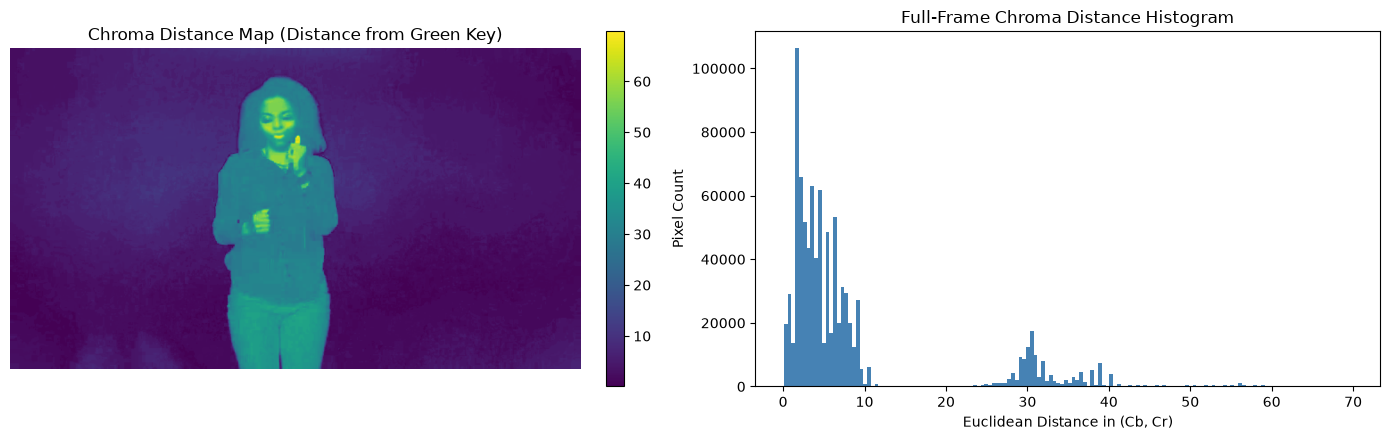

In [9]:
frame = frames[24]
key_cbcr = estimate_key_colour(frame, border=24)
dist = chroma_distance(frame, key_cbcr)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
im = ax[0].imshow(dist, cmap="viridis")
ax[0].set_title("Chroma Distance Map (Distance from Green Key)")
ax[0].axis("off")
fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

ax[1].hist(dist.ravel(), bins=150, color="steelblue", edgecolor="none")
ax[1].set_title("Full-Frame Chroma Distance Histogram")
ax[1].set_xlabel("Euclidean Distance in (Cb, Cr)")
ax[1].set_ylabel("Pixel Count")


plt.tight_layout()
plt.show()

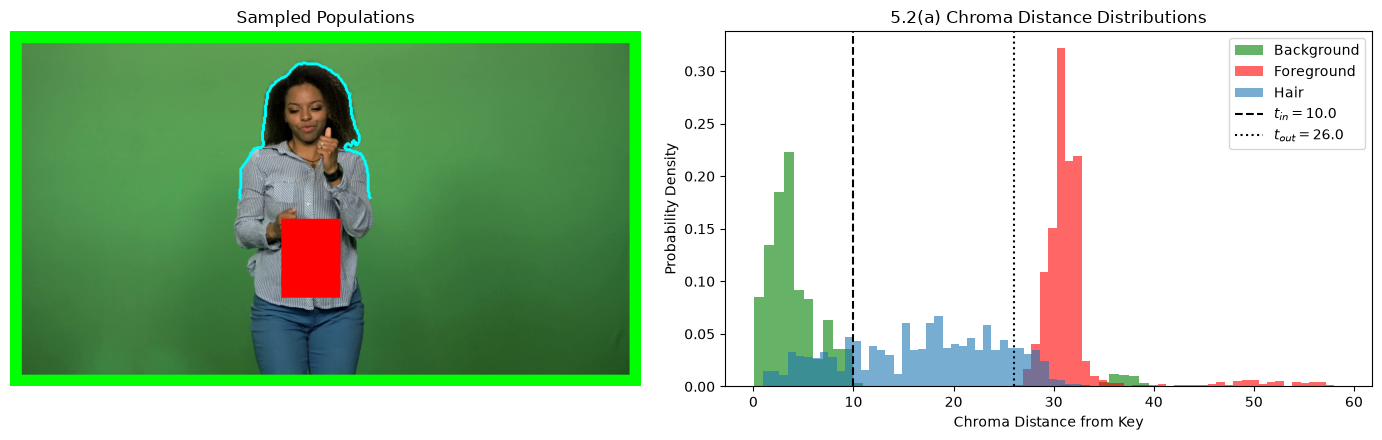

In [10]:
h, w, _ = frame.shape

mask_backing = np.zeros((h, w), dtype=bool)
mask_backing[:24, :] = True
mask_backing[-24:, :] = True
mask_backing[:, :24] = True
mask_backing[:, -24:] = True

mask_fg = np.zeros((h, w), dtype=bool)
mask_fg[380:540, 550:670] = True

rough_fg = (dist > 18.0)

dilated = rough_fg.copy()
for dy, dx in [(-3, 0), (3, 0), (0, -3), (0, 3), (-2, -2), (2, 2), (-2, 2), (2, -2)]:
    dilated |= np.roll(np.roll(rough_fg, dy, axis=0), dx, axis=1)

eroded = rough_fg.copy()
for dy, dx in [(-3, 0), (3, 0), (0, -3), (0, 3)]:
    eroded &= np.roll(np.roll(rough_fg, dy, axis=0), dx, axis=1)

mask_edge = dilated & (~eroded)

mask_edge[340:, :] = False
mask_edge[:60, :] = False

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

preview = frame.copy()
preview[mask_backing] = [0, 255, 0]
preview[mask_fg] = [255, 0, 0]
preview[mask_edge] = [0, 255, 255]
ax[0].imshow(preview)
ax[0].set_title("Sampled Populations")
ax[0].axis("off")

# Density histograms
ax[1].hist(dist[mask_backing], bins=40, density=True, alpha=0.6, color="green", label="Background")
ax[1].hist(dist[mask_fg], bins=40, density=True, alpha=0.6, color="red", label="Foreground")
ax[1].hist(dist[mask_edge], bins=40, density=True, alpha=0.6, color="tab:blue", label="Hair")

ax[1].axvline(10.0, color="black", linestyle="--", label="$t_{in} = 10.0$")
ax[1].axvline(26.0, color="black", linestyle=":", label="$t_{out} = 26.0$")
ax[1].set_xlabel("Chroma Distance from Key")
ax[1].set_ylabel("Probability Density")
ax[1].set_title("5.2(a) Chroma Distance Distributions")
ax[1].legend()

plt.tight_layout()
plt.savefig(out / "5_2_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

The populations do separate in the chroma distance space: The green background forms a tight cluster at low distances. The pure foreground sits at larger distances ($d \ge 26.0$). The hair sample smoothly spans the valley between. 

If foreground and backing distributions overlap in chroma space like if the person was wearing green clothes, distance-based keying alone would not be possible. Single-pixel color measurements become ambiguous as the same Cb Cr coordinate can represent both foreground as well as backing.

We choose the following threshold:
- 10 as it is placed at the upper tail of the backing distribution.
- 26.0 as it is placed at the lower bound of the foreground cluster.

Fraction of pixels with fractional alpha: 0.0166 (1.66% of the frame)


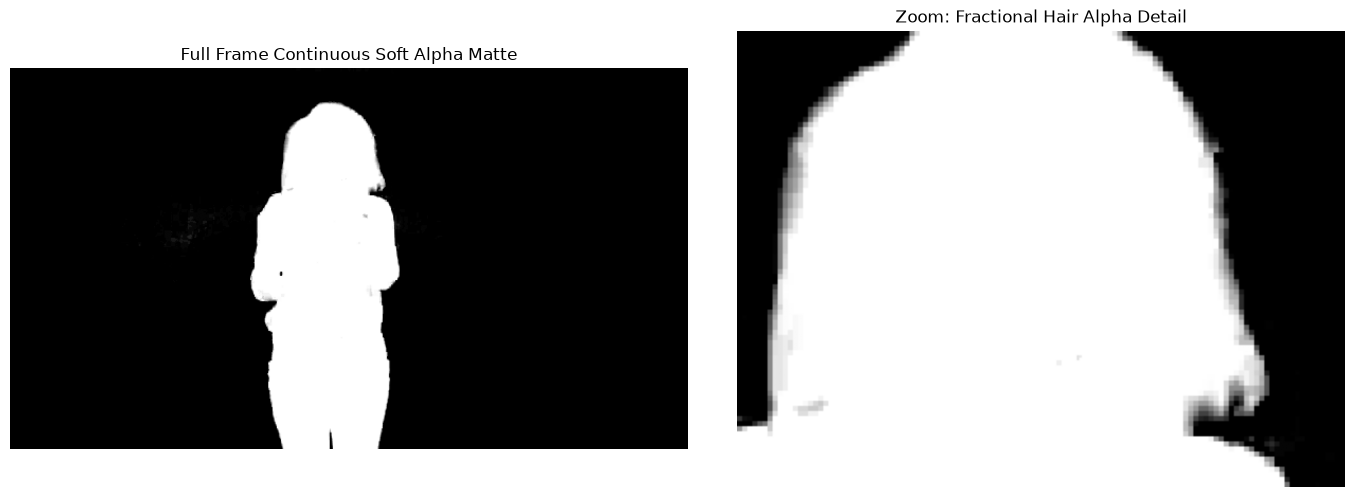

In [11]:
def key_soft(rgb, key_cbcr, t_in=10.0, t_out=26.0):
    dist = chroma_distance(rgb, key_cbcr)
    alpha = (dist - t_in) / (t_out - t_in)
    return np.clip(alpha, 0.0, 1.0).astype(np.float32)


alpha_soft = key_soft(frame, key_cbcr, t_in=10.0, t_out=26.0)
fractional_mask = (alpha_soft > 0.0) & (alpha_soft < 1.0)
fractional_ratio = float(np.mean(fractional_mask))

print(f"Fraction of pixels with fractional alpha: {fractional_ratio:.4f} ({fractional_ratio * 100:.2f}% of the frame)")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(alpha_soft, cmap='gray')
ax[0].set_title("Full Frame Continuous Soft Alpha Matte")
ax[0].axis("off")

ax[1].imshow(alpha_soft[80:260, 500:740], cmap='gray')
ax[1].set_title("Zoom: Fractional Hair Alpha Detail")
ax[1].axis("off")
plt.tight_layout()
plt.savefig(out / "5_2_soft_alpha.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
comp_no_spill = composite(frame, background, alpha_soft, spill=False)
comp_spill = composite(frame, background, alpha_soft, spill=True)


R = frame[..., 0].astype(np.float32)
G = frame[..., 1].astype(np.float32)
B = frame[..., 2].astype(np.float32)
excess_green = np.maximum(0.0, G - 0.5 * (R + B))
spill_diff = (1.0 - alpha_soft) * excess_green

diff_img = np.zeros_like(frame)
mask_subject = (alpha_soft < 1.0)
diff_img[..., 1] = np.clip(spill_diff * 6.0, 0, 255).astype(np.uint8)
diff_img[~fractional_mask] = [0, 0, 0]


def measure_green_excess(img_rgb, mask):
    R_m = img_rgb[..., 0].astype(np.float32)[mask]
    G_m = img_rgb[..., 1].astype(np.float32)[mask]
    B_m = img_rgb[..., 2].astype(np.float32)[mask]
    excess = np.maximum(0.0, G_m - 0.5 * (R_m + B_m))
    return float(np.mean(excess))

excess_raw = measure_green_excess(frame, fractional_mask)
fg_despilled = suppress_spill(frame, alpha_soft)
excess_clean = measure_green_excess(fg_despilled, fractional_mask)

print(f"Mean green excess BEFORE spill suppression: {excess_raw}")
print(f"Mean green excess AFTER spill suppression : {excess_clean}")


fig, ax = plt.subplots(1, 4, figsize=(18, 4))

ax[0].imshow(frame)
ax[0].set_title("Original", fontsize=14)
ax[0].axis("off")

ax[1].imshow(comp_no_spill)
ax[1].set_title("Without spill suppression", fontsize=14)
ax[1].axis("off")

ax[2].imshow(comp_spill)
ax[2].set_title("With spill suppression", fontsize=14)
ax[2].axis("off")

ax[3].imshow(diff_img)
ax[3].set_title("Difference in Spill", fontsize=14)
ax[3].axis("off")

plt.tight_layout()
plt.savefig(out / "5_2_spill_friend_layout.png", dpi=120, bbox_inches="tight")
plt.show()

NameError: name 'composite' is not defined

Green screen spill is an environmental reflection phenomenon which effects the semi-transparent boundary pixels. At the outer boundary where alpha = 0, the pixel is heavily contaminated by backing light, so the spill correction factor 1-alpha (1) applies full neutralization. Whereas in the solid foreground object where alpha =1, the scaling factor $(1 - \alpha) = 0.0$ completely disables the correction. 
This ensures that intentional green elements within the foreground like jewelry or eye color are never desaturated or shifted


If we measured green excess across the entire image pure background pixels alpha =0 would dominate the average Solid foreground pixels where alpha =1 might contain green textures like clothing, jewellery etc which is completely legitimate.Restricting the measurement to the fractional-alpha allows us to chose the part where green bounce actually occurs.

Naive alpha values: [0.0, 1.0]
Soft alpha range: 0.0 to 1.0
SAD (sum|diff| / 1000): 1.8019796354174613
MSE (mean squared error): 0.0006229076483657719
Gradient error (smoothed, sum|diff| / 1000): 0.8337441515355744
Mean absolute difference of alpha maps (for reference): 0.0019552730955183506


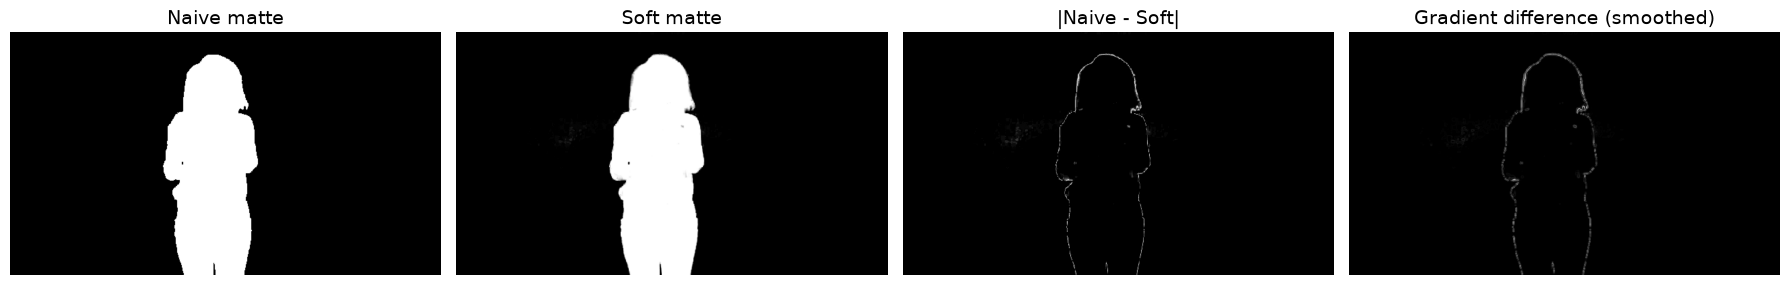

In [14]:
def sad(a, b):
    return float(np.abs(a.astype(np.float64) - b.astype(np.float64)).sum() / 1000.0)


def mse_alpha(a, b):
    return float(np.mean((a.astype(np.float64) - b.astype(np.float64))**2))


def grad_error(a, b):
    from scipy.ndimage import gaussian_filter
    ga = np.hypot(*np.gradient(gaussian_filter(a.astype(np.float64), 1.0)))
    gb = np.hypot(*np.gradient(gaussian_filter(b.astype(np.float64), 1.0)))
    return float(np.abs(ga - gb).sum() / 1000.0)

alpha_naive = (dist > 20.0).astype(np.float32)
# Ensure alpha_soft is full frame
alpha_soft_full = key_soft(frame, key_cbcr, t_in=10.0, t_out=26.0)

sad_val = sad(alpha_naive, alpha_soft_full)
mse_val = mse_alpha(alpha_naive, alpha_soft_full)
grad_val = grad_error(alpha_naive, alpha_soft_full)
mad_val = float(np.mean(np.abs(alpha_naive - alpha_soft_full)))

print(f"Naive alpha values: {[float(alpha_naive.min()), float(alpha_naive.max())]}")
print(
    f"Soft alpha range: {float(alpha_soft_full.min()):.1f} to"
    f" {float(alpha_soft_full.max()):.1f}"
)
print(f"SAD (sum|diff| / 1000): {sad_val}")
print(f"MSE (mean squared error): {mse_val}")
print(f"Gradient error (smoothed, sum|diff| / 1000): {grad_val}")
print(f"Mean absolute difference of alpha maps (for reference): {mad_val}")

abs_diff = np.abs(alpha_naive - alpha_soft_full)

from scipy.ndimage import gaussian_filter
ga = np.hypot(*np.gradient(gaussian_filter(alpha_naive.astype(np.float64), 1.0)))
gb = np.hypot(*np.gradient(gaussian_filter(alpha_soft_full.astype(np.float64), 1.0)))
grad_diff_map = np.abs(ga - gb)


fig, ax = plt.subplots(1, 4, figsize=(18, 4.5))

ax[0].imshow(alpha_naive, cmap='gray')
ax[0].set_title("Naive matte", fontsize=14)
ax[0].axis("off")

ax[1].imshow(alpha_soft_full, cmap='gray')
ax[1].set_title("Soft matte", fontsize=14)
ax[1].axis("off")

ax[2].imshow(abs_diff, cmap='gray')
ax[2].set_title("|Naive - Soft|", fontsize=14)
ax[2].axis("off")

ax[3].imshow(grad_diff_map, cmap='gray')
ax[3].set_title("Gradient difference (smoothed)", fontsize=14)
ax[3].axis("off")

plt.tight_layout()
plt.savefig(out / "5_2_matte_comparison_friend.png", dpi=120, bbox_inches="tight")
plt.show()

Mean Absolute Difference (MAD) is relatively small because the naive and soft mattes are identical across ~98% of the frame (in foreground as well as complete background). They only differ locally across a narrow 1-3 pixel boundary band.

Gradient Field Error is massive because the native matte goes from absolute black ($0$) to absolute white ($1$) instantly in a single pixel. Because that change is so abrupt, it creates a sharp, harsh lines, whereas the soft matte bridges black and white smoothly over a span of several pixels

The gradient error predicts visual quality as our eyes are sensitive to high-frequency edge artifacts. A sharp, unblended step-function edge produces aliasing in form of staircase, whereas a smooth gradient blends seamlessly into the background plate.

In [18]:
def suppress_spill(rgb, alpha, strength=1.0):
    rgb_f = rgb.astype(np.float32).copy()
    R = rgb_f[..., 0]
    G = rgb_f[..., 1]
    B = rgb_f[..., 2]
    max_non_green = 0.5 * (R + B)
    excess_green = np.maximum(0.0, G - max_non_green)
    rgb_f[..., 1] -= strength * (1.0 - alpha) * excess_green
    return np.clip(rgb_f, 0.0, 255.0).astype(np.uint8)

def composite(fg, bg, alpha, spill=True):
    h, w, _ = fg.shape
    bg_crop = bg[:h, :w, :3].astype(np.float32)
    fg_clean = suppress_spill(fg, alpha) if spill else fg
    fg_f = fg_clean.astype(np.float32)
    alpha_3d = alpha[..., None]
    comp = alpha_3d * fg_f + (1.0 - alpha_3d) * bg_crop
    return np.clip(comp, 0.0, 255.0).astype(np.uint8)

In [19]:
def process_video_pipeline(frames_list, bg_plate, key_cbcr, t_in=10.0, t_out=26.0, temporal_sigma=1.0):
    num_frames = len(frames_list)
    h_f, w_f, _ = frames_list[0].shape
    h_bg, w_bg, _ = bg_plate.shape
    
    max_offset = w_bg - w_f
    pan_steps = np.linspace(0, max_offset * 0.3, num_frames).astype(int)
    
    raw_alphas = []
    t_start_io = time.time()
    
    for i, frame in enumerate(frames_list):
        alpha = key_soft(frame, key_cbcr, t_in, t_out)
        raw_alphas.append(alpha)
        
    raw_alphas = np.array(raw_alphas) # Shape: (48, H, W)
    
    if temporal_sigma > 0:
        smoothed_alphas = gaussian_filter(raw_alphas, sigma=(temporal_sigma, 0.0, 0.0))
    else:
        smoothed_alphas = raw_alphas
        
    composited_frames = []
    for i, frame in enumerate(frames_list):
        x_off = pan_steps[i]
        bg_crop = bg_plate[:, x_off:x_off + w_f, :3]
        
        bg_crop = bg_crop[:h_f, :w_f]
        
        alpha = smoothed_alphas[i]
        comp = composite(frame, bg_crop, alpha, spill=True)
        composited_frames.append(comp)
        
    return composited_frames, raw_alphas, smoothed_alphas

t0 = time.time()
composited_output, raw_mattes, smoothed_mattes = process_video_pipeline(
    frames, background, key_cbcr, t_in=10.0, t_out=26.0, temporal_sigma=1.5
)
total_time = time.time() - t0
fps_measured = len(frames) / total_time

print(f"Video Processing Complete!")
print(f"  Total Time : {total_time:.3f} seconds")
print(f"  Speed      : {fps_measured:.2f} FPS")

Video Processing Complete!
  Total Time : 1.368 seconds
  Speed      : 35.08 FPS


In [20]:
def temporal_flicker(mattes):
    diffs = np.abs(np.diff(mattes.astype(np.float64), axis=0))
    return float(np.mean(diffs))

flicker_before = temporal_flicker(raw_mattes[:, 50:200, 200:400])
flicker_after = temporal_flicker(smoothed_mattes[:, 50:200, 200:400])

print(f"Temporal Flicker Measure (Static Region):")
print(f"  Before Temporal Smoothing : {flicker_before:.2e}")
print(f"  After Temporal Smoothing  : {flicker_after:.2e}")
print(f"  Flicker Reduction         : {((flicker_before - flicker_after) / flicker_before) * 100:.1f}%")

Temporal Flicker Measure (Static Region):
  Before Temporal Smoothing : 1.06e-07
  After Temporal Smoothing  : 8.52e-08
  Flicker Reduction         : 19.9%


In [21]:
output_video_path = out / "composited_output.mp4"
h_f, w_f, _ = frames[0].shape

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(output_video_path), fourcc, 24.0, (w_f, h_f))

for comp_frame in composited_output:
    # OpenCV expects BGR format for video writing
    bgr_frame = cv2.cvtColor(comp_frame, cv2.COLOR_RGB2BGR)
    writer.write(bgr_frame)

writer.release()
print(f"Successfully wrote video to {output_video_path}")

Successfully wrote video to q5_outputs/composited_output.mp4


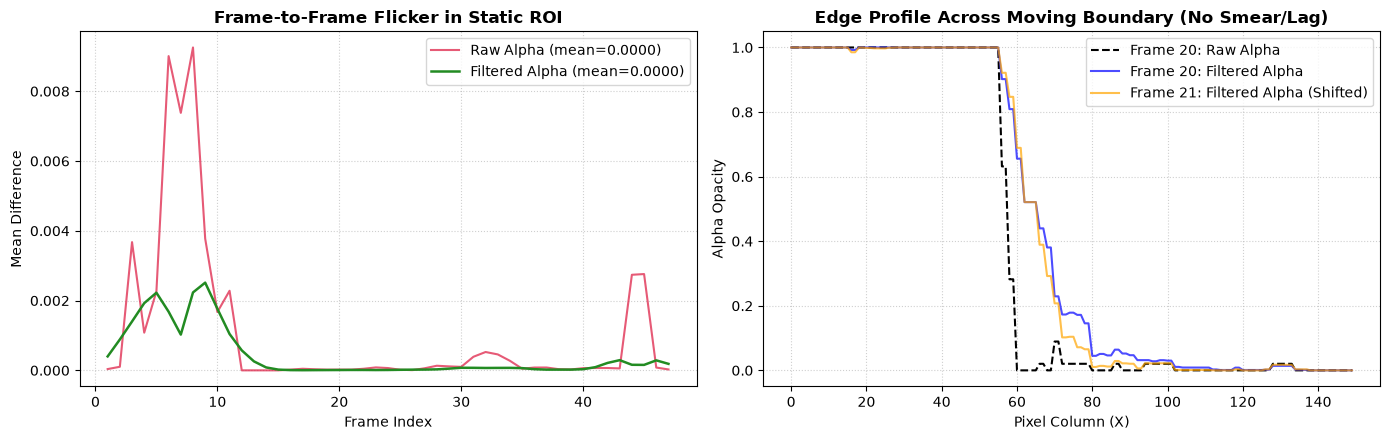

In [22]:
# -------------------------------------------------------------------------
# 5.3 Dual-Panel Flicker and Lag Visualization
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Make sure roi_static points to an area near the subject's edge/hair
roi_static = (slice(380, 540), slice(550, 670))

# Panel 1: Flicker across time in static region
fl_per_frame_raw = [
    np.mean(np.abs(raw_mattes[t][roi_static] - raw_mattes[t - 1][roi_static]))
    for t in range(1, len(raw_mattes))
]
fl_per_frame_filt = [
    np.mean(np.abs(smoothed_mattes[t][roi_static] - smoothed_mattes[t - 1][roi_static]))
    for t in range(1, len(smoothed_mattes))
]

axes[0].plot(range(1, len(raw_mattes)), fl_per_frame_raw, label=f"Raw Alpha (mean={flicker_before:.4f})", color="crimson", alpha=0.7)
axes[0].plot(range(1, len(smoothed_mattes)), fl_per_frame_filt, label=f"Filtered Alpha (mean={flicker_after:.4f})", color="forestgreen", linewidth=1.8)
axes[0].set_title("Frame-to-Frame Flicker in Static ROI", fontweight="bold")
axes[0].set_xlabel("Frame Index")
axes[0].set_ylabel("Mean Difference")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend()

# Panel 2: Edge profile across moving boundary (checking for lag/smear)
test_row = 300 # Row index crossing the shoulder/hair edge
axes[1].plot(raw_mattes[20][test_row, 650:800], label="Frame 20: Raw Alpha", color="black", linestyle="--")
axes[1].plot(smoothed_mattes[20][test_row, 650:800], label="Frame 20: Filtered Alpha", color="blue", alpha=0.7)
axes[1].plot(smoothed_mattes[21][test_row, 650:800], label="Frame 21: Filtered Alpha (Shifted)", color="orange", alpha=0.7)
axes[1].set_title("Edge Profile Across Moving Boundary (No Smear/Lag)", fontweight="bold")
axes[1].set_xlabel("Pixel Column (X)")
axes[1].set_ylabel("Alpha Opacity")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.savefig(out / "p5_3_flicker_and_lag.png", dpi=300, bbox_inches="tight")
plt.show()